In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path

import torch
from torch.utils.data import Dataset
from torchvision.transforms import Compose, ToTensor, Normalize, Resize, RandomHorizontalFlip, RandomVerticalFlip, RandomRotation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from transformers import AutoImageProcessor, AutoModelForImageClassification, TrainingArguments, Trainer

C:\Users\Mateusz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
BASE_DIR = Path(r"C:\Magisterka")
CSV_PATH = BASE_DIR / "luad_patches_with_splits_all_classes.csv"
df_subset = pd.read_csv(CSV_PATH)

df_train = df_subset[df_subset["split"] == "train"].reset_index(drop=True)
df_val = df_subset[df_subset["split"] == "val"].reset_index(drop=True)
df_test = df_subset[df_subset["split"] == "test"].reset_index(drop=True)

In [3]:
model_name = "google/vit-base-patch16-224"
processor = AutoImageProcessor.from_pretrained(model_name)

normalize = Normalize(mean=processor.image_mean, std=processor.image_std)

if "shortest_edge" in processor.size:
    IMG_SIZE = processor.size["shortest_edge"]
else:
    IMG_SIZE = processor.size["height"]

train_transforms = Compose([
    Resize((IMG_SIZE, IMG_SIZE)),
    RandomHorizontalFlip(),
    RandomVerticalFlip(),
    RandomRotation(20),
    ToTensor(),
    normalize
])
eval_transforms = Compose([
    Resize((IMG_SIZE, IMG_SIZE)),
    ToTensor(),
    normalize
])

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


In [4]:
class PatchDataset(Dataset):
    def __init__(self, df_subset, transforms):
        self.df = df_subset
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]
        img_path = row["image_path"]
        label_id = int(row["dominant_label_id"])
        
        img = Image.open(img_path).convert("RGB")
        pixel_values = self.transforms(img)
        
        return {"pixel_values": pixel_values, "labels": label_id}
    
train_dataset = PatchDataset(df_train, train_transforms)
val_dataset = PatchDataset(df_val, eval_transforms)
test_dataset = PatchDataset(df_test, eval_transforms)

In [5]:
id2label = {0: "background", 1: "cribriform", 2: "micropapillary", 
    3: "solid", 4: "papillary", 5: "acinar", 6: "lepidic"}

label2id = {v: k for k, v in id2label.items()}

model = AutoModelForImageClassification.from_pretrained(
    model_name,
    num_labels=len(id2label),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    acc = accuracy_score(labels, preds)
    
    f1 = f1_score(labels, preds, average="macro", zero_division=0)
    precision = precision_score(labels, preds, average="macro", zero_division=0)
    recall = recall_score(labels, preds, average="macro", zero_division=0)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 648.14it/s, Materializing param=vit.layernorm.weight]                                 
ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([7, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([7])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [6]:
training_args = TrainingArguments(
    output_dir=str(BASE_DIR / "vit_base_patch16_224_luad_results"),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=1e-4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=10,
    weight_decay=1e-4,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=True,
    dataloader_num_workers=0,
    remove_unused_columns=False
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)
print("Starting training on device: ", trainer.args.device)
trainer.train()

print("Evaluating on test set...")
test_results = trainer.evaluate(test_dataset)
print("Test set results:", test_results)

Starting training on device:  cuda:0


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.242425,0.812438,0.763636,0.335145,0.475353,0.314560
2,0.653232,0.646438,0.763636,0.380695,0.447041,0.363400
3,0.462173,0.754779,0.754545,0.354956,0.471070,0.316392
4,0.345199,0.699402,0.772727,0.394220,0.463057,0.374389
5,0.223633,0.664395,0.800000,0.431111,0.455618,0.438187
6,0.154250,0.764561,0.772727,0.377477,0.466292,0.347375
7,0.159849,0.783407,0.809091,0.436029,0.482583,0.407967
8,0.066880,0.767634,0.781818,0.408816,0.458268,0.389194
9,0.056874,0.756859,0.772727,0.402708,0.472029,0.369200
10,0.028009,0.792492,0.763636,0.393808,0.450904,0.367216


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.90it/s]


Evaluating on test set...


Test set results: {'eval_loss': 0.4622175991535187, 'eval_accuracy': 0.8272727272727273, 'eval_f1': 0.39063549470421083, 'eval_precision': 0.4266870384517444, 'eval_recall': 0.37630588589492703, 'eval_runtime': 10.0497, 'eval_samples_per_second': 10.946, 'eval_steps_per_second': 0.398, 'epoch': 10.0}


Generating predictions for test set...

Classification Report:
                precision    recall  f1-score   support

    background       0.84      0.97      0.90        73
    cribriform       0.50      0.20      0.29         5
micropapillary       0.00      0.00      0.00         2
         solid       0.82      0.69      0.75        13
     papillary       0.83      0.77      0.80        13
        acinar       0.00      0.00      0.00         1
       lepidic       0.00      0.00      0.00         3

      accuracy                           0.83       110
     macro avg       0.43      0.38      0.39       110
  weighted avg       0.77      0.83      0.79       110

Macierz pomyłek została zapisana do: C:\Magisterka\confusion_matrix_vit.png


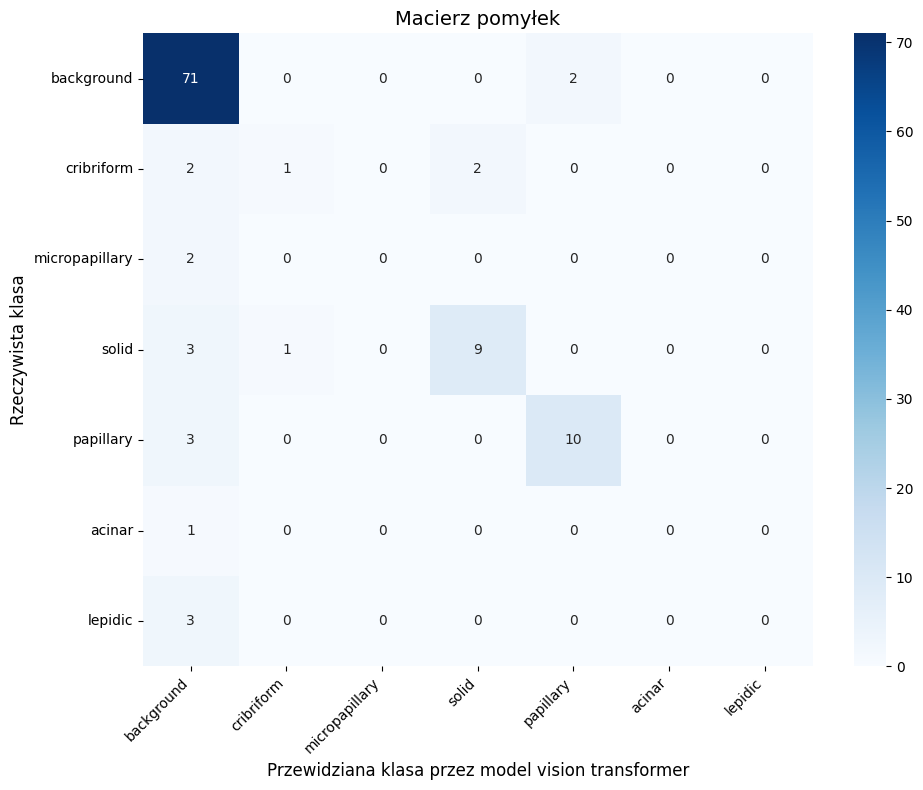

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("Generating predictions for test set...")
prediction_outputs = trainer.predict(test_dataset)

predictions = np.argmax(prediction_outputs.predictions, axis=1)
true_labels = prediction_outputs.label_ids

class_names = [id2label[i] for i in range(len(id2label))]

print("\n" + "="*50)
print("Classification Report:")
print("="*50)
report = classification_report(true_labels, predictions, target_names=class_names, zero_division=0)
print(report)

cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Przewidziana klasa przez model vision transformer", fontsize=12)
plt.ylabel("Rzeczywista klasa", fontsize=12)
plt.title("Macierz pomyłek", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

cm_path = BASE_DIR / "confusion_matrix_vit.png"
plt.savefig(cm_path, dpi=300)
print(f"Macierz pomyłek została zapisana do: {cm_path}")
plt.show()